# Phylogenetic trees: simulate, fit, search, learn

One pass through the repository's phylogenetic instance, from a seeded
alignment to a learned proposal policy. Six taxa throughout, because that is
where all 105 unrooted topologies can be enumerated — which is what turns
"the search found the best tree" from an assertion into a checkable claim.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from snakes_and_ladders.learn.policy import LinearPolicy
from snakes_and_ladders.learn.reinforce import reinforce
from snakes_and_ladders.learn.rollout import greedy_rollout, rollout
from snakes_and_ladders.likelihood.brute_force import brute_force_log_likelihood
from snakes_and_ladders.likelihood.objective import BranchLengthObjective
from snakes_and_ladders.likelihood.pruning import log_likelihood
from snakes_and_ladders.opt.fit import constrained_standard_errors, covers, fit
from snakes_and_ladders.search.infer import MoveSet, infer, score_topology
from snakes_and_ladders.search.rl import RewardModel, TopologyEnvironment
from snakes_and_ladders.search.topology import (
    enumerate_topologies,
    leaf_bipartitions,
    normalized_robinson_foulds,
)
from snakes_and_ladders.sim.params import load_simulation_params
from snakes_and_ladders.sim.simulate import simulate_alignment
from snakes_and_ladders.sim.tree import edges

# Resolve the repository root from wherever the notebook is opened.
REPOSITORY = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").is_file()
)
FIXTURE = REPOSITORY / "tests/regression/fixtures/simulation_params_6taxa.yaml"

params = load_simulation_params(FIXTURE)
branch_lengths = {child.name: child.branch_length for _, child in edges(params.tau)}
print(f"taxa   {sorted(name for name in branch_lengths if len(name) == 1)}")
print(f"states {params.k}, sites {params.n_sites}, seed {params.seed}")
print("generating branch lengths:")
for name, value in branch_lengths.items():
    print(f"  {name:<14}{value:.2f}")

taxa   ['A', 'B', 'C', 'D', 'E', 'F']
states 4, sites 1500, seed 20260905
generating branch lengths:
  A             0.12
  B             0.28
  ancestor_CDEF 0.06
  ancestor_CD   0.09
  C             0.21
  D             0.07
  ancestor_EF   0.14
  E             0.33
  F             0.18


## 1. A simulated alignment, and the tree that produced it

The fixture declares the topology, the branch lengths and the root
distribution; the simulator draws states down the tree under a seeded
generator and retains the truth beside the data.

In [2]:
dataset = simulate_alignment(
    tau=params.tau, k=params.k, pi=params.pi, seed=params.seed, n_sites=params.n_sites
)
alignment = dict(dataset.alignment)
print(f"{len(alignment)} taxa x {params.n_sites} sites")
print("first 20 sites:")
for name in sorted(alignment):
    print(f"  {name}  {''.join(str(state) for state in alignment[name][:20])}")

6 taxa x 1500 sites
first 20 sites:
  A  23311112321210212103
  B  13311300321010232123
  C  13311320321130223103
  D  13311112321130222003
  E  11311112321230320123
  F  11311112022233212123


## 2. The likelihood, against brute-force marginalization

Felsenstein's pruning recursion computes the likelihood in `O(n k^2)` per
site by summing over ancestral states as it goes. The oracle sums over every
ancestral assignment explicitly — `k` to the power of the number of internal
nodes, per site — so it shares no code with the recursion and cannot agree
with it by construction.

The check runs on a 4-taxon subtree because the enumeration is what costs.

In [3]:
SUBSET_SITES = 200

subtree = params.tau.children[2]
subset = {
    name: alignment[name][:SUBSET_SITES]
    for name in sorted(alignment)
    if name in {leaf.name for leaf in subtree.children[0].children}
    or name in {leaf.name for leaf in subtree.children[1].children}
}
pi = np.asarray(params.pi)

recursion = log_likelihood(subtree, params.k, pi, subset)
enumerated = brute_force_log_likelihood(subtree, params.k, pi, subset)
print(f"pruning recursion:          {recursion:.12f}")
print(f"brute-force marginalization:{enumerated:.12f}")
print(f"relative deviation {abs((recursion - enumerated) / enumerated):.2e}")

pruning recursion:          -854.681084209067
brute-force marginalization:-854.681084209067
relative deviation 1.33e-16


## 3. Fitting branch lengths on a fixed topology

The same `snakes_and_ladders.opt.fit` that fits the Potts coupling in `potts_chain.ipynb`
and the hidden Markov transition matrix in `hmm.ipynb`, unchanged: it sees an
unconstrained vector, a differentiable scalar, and a map back to named
parameters. It does not know what a tree is.

In [4]:
objective = BranchLengthObjective(params.tau, params.k, pi, alignment)
result = fit(objective)
estimate = objective.constrain(result.theta)["branch_lengths"]
error = constrained_standard_errors(objective, result.theta)["branch_lengths"]
names = objective.parameter_names
truth = torch.tensor([branch_lengths[name] for name in names], dtype=torch.float64)
hits = covers(estimate, error, truth)

print(
    f"converged: {result.converged}, {result.iterations} L-BFGS steps, "
    f"relative gradient norm {result.gradient_norm:.2e}"
)
# `fit` minimizes, so the objective is the negative log-likelihood.
print(f"maximized log-likelihood {-result.value:.4f}\n")
print(f"{'branch':<16}{'truth':>9}{'fitted':>9}{'std err':>9}   95% interval")
for name, true_value, point, spread, covered in zip(
    names, truth, estimate, error, hits, strict=True
):
    print(
        f"{name:<16}{float(true_value):>9.4f}{float(point):>9.4f}"
        f"{float(spread):>9.4f}   {'covers' if bool(covered) else 'MISSES'}"
    )
print(f"\n{int(hits.sum())} of {len(hits)} intervals cover their truth")

converged: True, 1 L-BFGS steps, relative gradient norm 2.79e-12
maximized log-likelihood -8775.5427

branch              truth   fitted  std err   95% interval
A                  0.1200   0.1093   0.0112   covers
B                  0.2800   0.2667   0.0167   covers
ancestor_CDEF      0.0600   0.0731   0.0108   covers
ancestor_CD        0.0900   0.0661   0.0102   MISSES
C                  0.2100   0.2386   0.0153   covers
D                  0.0700   0.0699   0.0090   covers
ancestor_EF        0.1400   0.1431   0.0150   covers
E                  0.3300   0.3349   0.0203   covers
F                  0.1800   0.1747   0.0153   covers

8 of 9 intervals cover their truth


## 4. Discrete search over topologies

Branch lengths are continuous and the topology is not. `infer` climbs over a
neighbourhood — NNI or SPR — refitting the continuous parameters of every
candidate it scores, and counts its budget in candidate fits rather than
seconds so a run reproduces from its seed.

In [5]:
MAX_EVALUATIONS = 500

searches = {}
for moves in (MoveSet.NNI, MoveSet.SPR):
    searches[moves] = infer(
        alignment, params.k, seed=0, moves=moves, max_evaluations=MAX_EVALUATIONS
    )
    outcome = searches[moves]
    print(
        f"{moves.value:<5} log-likelihood {outcome.log_likelihood:.4f}  "
        f"candidate fits {outcome.evaluations:>3}  accepted moves "
        f"{len(outcome.trace) - 1}"
    )

nni   log-likelihood -8775.5427  candidate fits  14  accepted moves 2


spr   log-likelihood -8775.5427  candidate fits  48  accepted moves 1


## 5. Validation against the enumerated truth

Two independent references. Exhaustive enumeration answers "is this the
highest-scoring topology"; the generating tree answers "is it the right one".
Normalized Robinson-Foulds counts internal splits only — every tree over the
same leaves induces all the trivial ones, and counting them would shrink every
distance by a taxon-count-dependent factor.

In [6]:
scores = np.array(
    sorted(
        score_topology(topology, alignment, params.k)
        for topology in enumerate_topologies(sorted(alignment))
    )
)
generating = score_topology(params.tau, alignment, params.k)

print(f"{len(scores)} unrooted topologies enumerated and scored")
print(f"best enumerated  {scores[-1]:.4f}")
print(f"runner-up        {scores[-2]:.4f}  (behind by {scores[-1] - scores[-2]:.1f})")
print(f"generating tree  {generating:.4f}\n")
for moves, outcome in searches.items():
    found = abs(outcome.log_likelihood - scores[-1]) < 1e-6
    distance = normalized_robinson_foulds(outcome.topology, params.tau)
    print(
        f"{moves.value:<5} reached the enumerated maximum: {found}   "
        f"normalized RF to the generating tree: {distance:.2f}"
    )
print(
    "\nsame leaf bipartitions as the generating tree: "
    f"{leaf_bipartitions(searches[MoveSet.NNI].topology) == leaf_bipartitions(params.tau)}"
)

105 unrooted topologies enumerated and scored
best enumerated  -8775.5427
runner-up        -8817.1116  (behind by 41.6)
generating tree  -8775.5427

nni   reached the enumerated maximum: True   normalized RF to the generating tree: 0.00
spr   reached the enumerated maximum: True   normalized RF to the generating tree: 0.00

same leaf bipartitions as the generating tree: True


## 6. Training data, and a learned proposal policy

The search above is a Markov decision process: a state is a topology, an
action is a neighbour, and the reward is the improvement in log-likelihood.

The reward model matters more than the agent. Refitting branch lengths per
candidate costs 113.7 ms against 352 us at fixed known parameters — a factor
of 323 — and only the second makes an episode affordable. The substitution is
validated rather than assumed: the two surfaces correlate at 0.9568 and agree
on the best of all 105 topologies (`docs/tex/figures/rl_reward_surface.pdf`).

In [7]:
ITERATIONS, BATCH, HORIZON = 40, 16, 8

mean_branch_length = float(np.mean(list(branch_lengths.values())))
environment = TopologyEnvironment(
    alignment,
    params.k,
    pi,
    branch_length=mean_branch_length,
    reward=RewardModel.KNOWN,
    moves=MoveSet.NNI,
)
policy = LinearPolicy(environment.n_features())
training = reinforce(
    environment,
    policy,
    np.random.default_rng(1),
    iterations=ITERATIONS,
    batch=BATCH,
    max_steps=HORIZON,
)
print(f"fixed branch length {mean_branch_length:.4f} (the generating tree's mean)")
print(
    f"{training.episodes} episodes sampled; {environment.evaluations} distinct "
    "topologies scored"
)
print(f"learned weights {policy.weights.detach().numpy().round(4)}")

fixed branch length 0.1644 (the generating tree's mean)
640 episodes sampled; 105 distinct topologies scored
learned weights [0.3086]


## 7. The best likelihood reached, against the data likelihood at truth

The comparison the ticket asks for. Every number below is on the cheap
reward's scale — fixed branch lengths at the generating mean — so the
reference line is the generating topology scored the same way, not the fitted
maximum from §3.

In [8]:
PROBE_STARTS, ROLLOUTS_PER_START = 12, 8

probe_rng = np.random.default_rng(7)
start_rng = np.random.default_rng(5)
probes = [environment.reset(start_rng) for _ in range(PROBE_STARTS)]

at_truth = environment.score(params.tau)
enumerated_best = max(
    environment.score(topology) for topology in enumerate_topologies(sorted(alignment))
)

greedy_episodes = [greedy_rollout(environment, start, HORIZON) for start in probes]
learned_episodes = [
    rollout(environment, policy, probe_rng, HORIZON, start=start)
    for start in probes
    for _ in range(ROLLOUTS_PER_START)
]


def best_reached(episodes):
    return [
        max(environment.score(state) for state in episode.states)
        for episode in episodes
    ]


greedy_best = best_reached(greedy_episodes)
learned_best = best_reached(learned_episodes)

print(f"{'':<24}{'mean best lnL':>15}{'reached the max':>18}")
for label, values in (
    ("hill climbing", greedy_best),
    ("learned policy", learned_best),
):
    reached = np.mean([abs(value - enumerated_best) < 1e-6 for value in values])
    print(f"{label:<24}{np.mean(values):>15.2f}{reached:>17.1%}")
print(f"{'generating topology':<24}{at_truth:>15.2f}")
print(f"{'enumerated maximum':<24}{enumerated_best:>15.2f}")
print(
    "\nthe generating topology is the enumerated maximum on this fixture: "
    f"{abs(at_truth - enumerated_best) < 1e-9}"
)

                          mean best lnL   reached the max
hill climbing                  -8976.31           100.0%
learned policy                 -8976.31           100.0%
generating topology            -8976.31
enumerated maximum             -8976.31

the generating topology is the enumerated maximum on this fixture: True


Both searchers reach the maximum from every start. That is the fixture
talking, not the agent: greedy already solves it, so this notebook cannot
separate a policy from hill climbing in either direction. Issue #177 carries a
fixture hard enough to try, and #178 the claim that would rest on it.

## 8. Log-likelihood against step within an episode

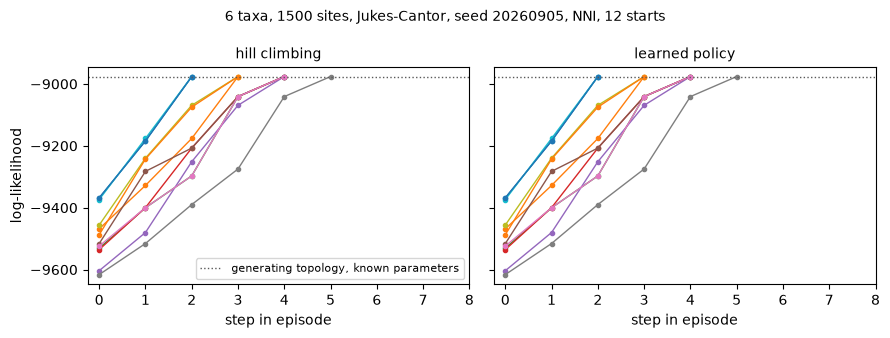

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(9.0, 3.4), sharey=True)

for axis, label, episodes in (
    (axes[0], "hill climbing", greedy_episodes),
    (axes[1], "learned policy", learned_episodes[::ROLLOUTS_PER_START]),
):
    for episode in episodes:
        trace = [environment.score(state) for state in episode.states]
        axis.plot(range(len(trace)), trace, marker="o", markersize=3, linewidth=1.0)
    axis.axhline(
        at_truth,
        color="0.35",
        linestyle=":",
        linewidth=1.0,
        label="generating topology, known parameters",
    )
    axis.set_title(label, fontsize=10)
    axis.set_xlabel("step in episode")
    axis.set_xticks(range(HORIZON + 1))
axes[0].set_ylabel("log-likelihood")
axes[0].legend(fontsize=8, loc="lower right")
figure.suptitle(
    f"6 taxa, {params.n_sites} sites, Jukes-Cantor, seed {params.seed}, "
    f"NNI, {PROBE_STARTS} starts",
    fontsize=10,
)
figure.tight_layout()
plt.show()

The two panels agree because the policy class contains the baseline: with a
single feature — the improvement a move buys — a softmax over that feature is
hill climbing up to temperature. Separating the two needs both a harder
fixture (#177) and features greedy cannot express.

## Further work

What this notebook could not demonstrate, because the feature is not built.
Each line names the issue that carries it.

- **A fixture that separates a policy from greedy (#177).** §7 is a null
  result by construction: hill climbing reaches the enumerated maximum from
  every start, so no agent can beat it here. Every Stage 2 claim needs a
  problem the baseline does not already solve.
- **A trained phylogenetic policy as a result (#178).** The policy in §6 is
  trained and it runs; what is missing is a problem on which its performance
  means something, and a budget-matched comparison over training seeds. The
  learning claim `STATUS.md` records is on the Potts landscape, not on trees.
- **A richer feature set (`TICKETS.md` §2.1).** The policy scores each move by
  one feature, the improvement it buys, which makes it a reparameterized
  greedy searcher. Separating the two needs features greedy cannot express.
- **Comparison against established software (#126).** IQ-TREE 2 and RAxML-NG
  are not installed, so no statement here compares against them.
- **Scaling past 8 taxa.** Exhaustive enumeration is the oracle every
  validation above rests on, and it is affordable only below 8 taxa. Above it
  the reference has to change, and what replaces it is stated in #177.
- **Re-execution in CI.** This notebook is committed with its outputs, and no
  job re-runs it: Jupyter is not a dependency of this repository. Unlike the
  figures in `docs/tex/`, which CI regenerates and byte-compares on every
  pull request, these numbers date from the commit that wrote them.